#**Packages**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#**Composite Quadrature Methods**

In [2]:
def composite_midpoint(f, a, b, m):
    Hm = (b - a) / m  # Width of each subinterval
    midpoints = np.linspace(a + Hm/2, b - Hm/2, m)  # Midpoints of subintervals
    integral = Hm * np.sum(f(midpoints))  # Apply the midpoint rule
    return integral

def composite_trapezoidal(f, a, b, m):
    Hm = (b - a) / m  # Width of each subinterval
    x = np.linspace(a, b, m+1)  # Node points
    integral = (Hm/2) * (f(x[0]) + f(x[-1]) + 2 * np.sum(f(x[1:-1])))  # Apply trapezoidal rule
    return integral

def composite_simpsons_first(f, a, b, m):
    Hm = (b - a) / m  # Width of each subinterval
    x = np.linspace(a, b, m + 1)  # Mesh of endpoints

    # Compute the integral using Simpson's Rule
    integral = (Hm / 6) * (
        f(x[0]) + f(x[-1]) +  # f(a) and f(b)
        2 * np.sum(f(x[1:-1])) +  # Sum of function values at all interior points
        4 * np.sum(f(x[:-1] + Hm / 2))  # Sum of function values at midpoints of each subinterval
    )
    return integral

def composite_left_rectangle(f, a, b, m):
    Hm = (b - a) / m  # Width of each subinterval
    x = np.linspace(a, b - Hm, m)  # Left endpoints of each subinterval
    integral = Hm * np.sum(f(x))  # Apply left rectangle rule
    return integral

def composite_open_newton_cotes(f, a, b, m):
    Hm = (b - a) / m  # Width of each subinterval

    integral = 0
    for i in range(m):
        x0 = a + i * Hm
        x1 = x0 + Hm / 3
        x2 = x0 + 2 * Hm / 3

        integral += (Hm / 2) * (f(x1) + f(x2))
    return integral

def composite_gauss_legendre(f, a, b, m):
    Hm = (b - a) / m  # Width of each subinterval

    # Gauss-Legendre nodes and weights for two-point rule
    nodes = np.array([-np.sqrt(1/3), np.sqrt(1/3)])

    integral = 0
    for i in range(m):
        x0 = a + i * Hm
        x1 = a + (i + 1) * Hm

        # Transform nodes to the current subinterval
        x_nodes = ((x1 - x0) / 2) * nodes + (x0 + x1) / 2
        integral += (x1 - x0) / 2 * np.sum(f(x_nodes))

    return integral


def f(x):
    return x**2

a, b = 0, 3  # Interval
m = 10  # Number of subintervals

print("Midpoint Rule:", composite_midpoint(f, a, b, m))
print("Trapezoidal Rule:", composite_trapezoidal(f, a, b, m))
print("Simpson's Rule:", composite_simpsons_first(f, a, b, m))
print("Left Rectangle Rule:", composite_left_rectangle(f, a, b, m))
print("Open Newton-Cotes Two-Point Rule:", composite_open_newton_cotes(f, a, b, m))
print("Gauss-Legendre Two-Point Rule:", composite_gauss_legendre(f, a, b, m))




Midpoint Rule: 8.977500000000001
Trapezoidal Rule: 9.045
Simpson's Rule: 8.999999999999998
Left Rectangle Rule: 7.695000000000001
Open Newton-Cotes Two-Point Rule: 8.985
Gauss-Legendre Two-Point Rule: 9.0


#**Evaluation of Correctness of Codes**

##**Error Convergence Rates**

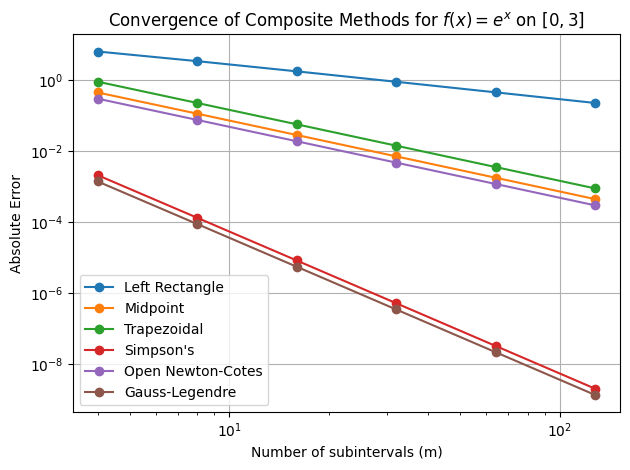

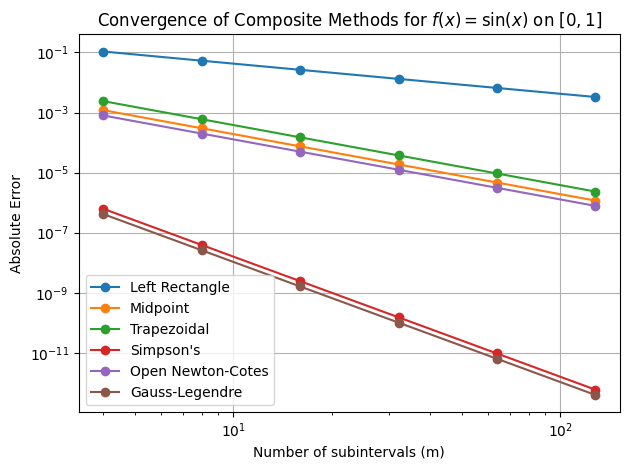

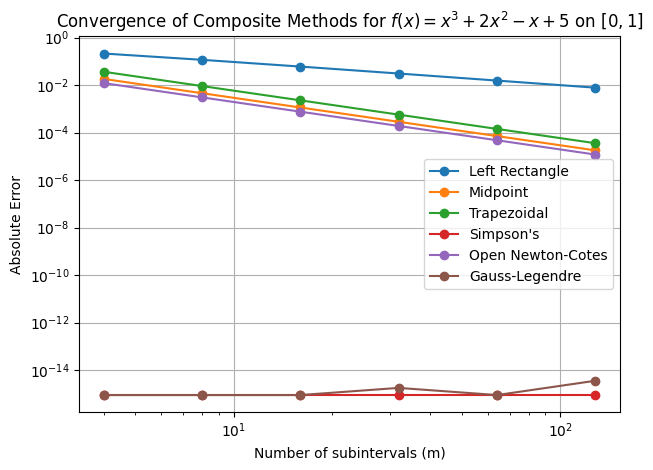

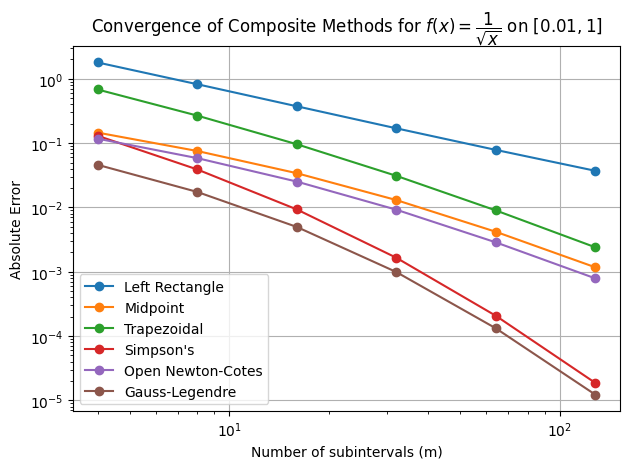

In [8]:
# Test functions
def f1(x):
    return np.exp(x)
def f2(x):
    return np.sin(x)
def f3(x):
    return x**3 + 2*x**2 - x + 5
def f4(x):
    return 1 / np.sqrt(x)

functions = {
    r"$f(x) = e^x$ on $[0, 3]$": (f1, 0, 3),
    r"$f(x) = \sin(x)$ on $[0, 1]$": (f2, 0, 1),
    r"$f(x) = x^3 + 2x^2 - x + 5$ on $[0, 1]$": (f3, 0, 1),
    r"$f(x) = \dfrac{1}{\sqrt{x}}$ on $[0.01, 1]$": (f4, 0.01, 1)
}

# Exact values
exact_integrals = {
    r"$f(x) = e^x$ on $[0, 3]$": np.exp(3) - 1,
    r"$f(x) = \sin(x)$ on $[0, 1]$": 1 - np.cos(1),
    r"$f(x) = x^3 + 2x^2 - x + 5$ on $[0, 1]$": (1**4)/4 + (2*1**3)/3 - (1**2)/2 + 5*1,
    r"$f(x) = \dfrac{1}{\sqrt{x}}$ on $[0.01, 1]$": 2 * (np.sqrt(1) - np.sqrt(0.01))
}

# Method dictionary
methods = {
    "Left Rectangle": composite_left_rectangle,
    "Midpoint": composite_midpoint,
    "Trapezoidal": composite_trapezoidal,
    "Simpson's": composite_simpsons_first,
    "Open Newton-Cotes": composite_open_newton_cotes,
    "Gauss-Legendre": composite_gauss_legendre
}

m_values = [4, 8, 16, 32, 64, 128]

# Compute and plot errors
results = {}
for label, (func, a, b) in functions.items():
    exact = exact_integrals[label]
    results[label] = {}
    for mname, method in methods.items():
        errors = []
        for m in m_values:
            approx = method(func, a, b, m)
            error = abs(approx - exact)
            errors.append(error)
        results[label][mname] = errors

    # Plotting per function
    plt.figure()
    for mname in methods.keys():
        plt.loglog(m_values, results[label][mname], label=mname, marker='o')
    plt.title(f"Convergence of Composite Methods for {label}")
    plt.xlabel("Number of subintervals (m)")
    plt.ylabel("Absolute Error")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()





##**Error Bound**

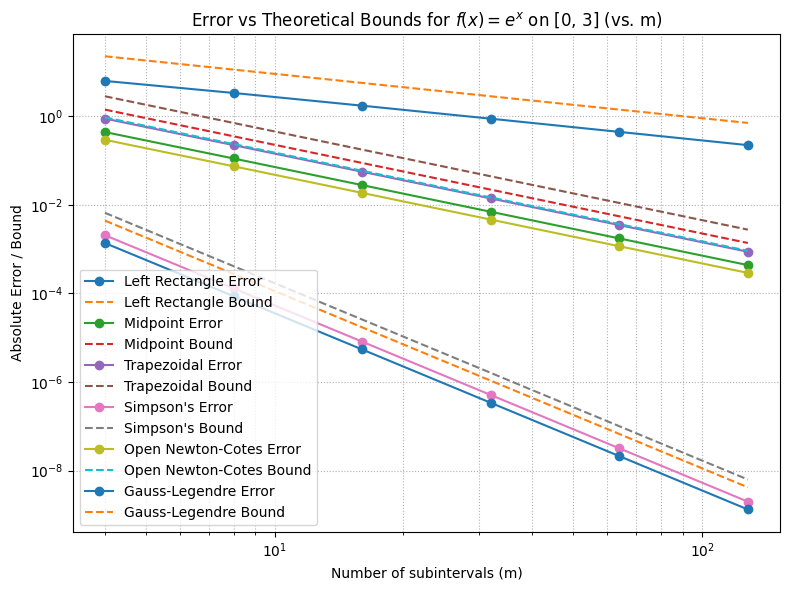

In [ ]:
#Define test function and parameters
def f1(x):
    return np.exp(x)
a, b = 0, 3
Hm = b - a
m_values = [4, 8, 16, 32, 64, 128]
H_vals = np.array([(b - a) / m for m in m_values])

# Function max derivatives for f(x) = e^x
max_1deriv = np.exp(3)  # max value of f' over [0,3]
max_2deriv = np.exp(3)  # max value of f'' over [0,3]
max_4deriv = np.exp(3)  # max value of f'''' over [0,3]

methods = {
    "Left Rectangle": composite_left_rectangle,
    "Midpoint": composite_midpoint,
    "Trapezoidal": composite_trapezoidal,
    "Simpson's": composite_simpsons_first,
    "Open Newton-Cotes": composite_open_newton_cotes,
    "Gauss-Legendre": composite_gauss_legendre
}

# Compute actual errors
exact = np.exp(3) - 1
actual_errors = {}
for mname, method in methods.items():
    actual_errors[mname] = [abs(method(f1, a, b, m) - exact) for m in m_values]

# Theoretical bounds using provided error constants
bounds_precise = {
    "Left Rectangle": (Hm / 2) * H_vals * max_1deriv,
    "Midpoint": (Hm / 24) * H_vals**2 * max_2deriv,
    "Trapezoidal": (Hm / 12) * H_vals**2 * max_2deriv,
    "Simpson's": (Hm / 2880) * H_vals**4 * max_4deriv,
    "Open Newton-Cotes": (Hm / 36) * H_vals**2 * max_2deriv,
    "Gauss-Legendre": (Hm / 4320) * H_vals**4 * max_4deriv
}

# Plot
plt.figure(figsize=(8, 6))

for mname in methods.keys():
    plt.loglog(m_values, actual_errors[mname], label=f"{mname} Error", marker='o')
    # Adjust the bounds to also be plotted against m_values (H = Hm/m)
    H_for_m = np.array([(b - a) / m for m in m_values])
    if mname == "Left Rectangle":
        bound = (Hm / 2) * H_for_m * max_1deriv
    elif mname == "Midpoint":
        bound = (Hm / 24) * H_for_m**2 * max_2deriv
    elif mname == "Trapezoidal":
        bound = (Hm / 12) * H_for_m**2 * max_2deriv
    elif mname == "Simpson's":
        bound = (Hm / 2880) * H_for_m**4 * max_4deriv
    elif mname == "Open Newton-Cotes":
        bound = (Hm / 36) * H_for_m**2 * max_2deriv
    elif mname == "Gauss-Legendre":
        bound = (Hm / 4320) * H_for_m**4 * max_4deriv
    plt.loglog(m_values, bound, linestyle='--', label=f"{mname} Bound")

plt.title("Error vs Theoretical Bounds for $f(x) = e^x$ on [0, 3] (vs. m)")
plt.xlabel("Number of subintervals (m)")
plt.ylabel("Absolute Error / Bound")
plt.legend()
plt.grid(True, which="both", ls=":")
plt.tight_layout()



#**Optimal Subinterval Sizes**

In [7]:
# Test functions
def f1(x):
    return np.exp(x)
def f2(x):
    return np.exp(np.sin(2 * x)) * np.cos(2 * x)
def f3(x):
    return np.tanh(x)
def f4(x):
    return x * np.cos(2 * np.pi * x)
def f5(x):
    return x + 1 / x

# Bounds
f1a, f1b = 0, 3
f2a, f2b = 0, np.pi / 3
f3a, f3b = -2, 1
f4a, f4b = 0, 3.5
f5a, f5b = 0.1, 2.5

# Exact integral values
f1_exact = np.exp(3) - 1
f2_exact = 0.5 * (-1 + np.exp(np.sqrt(3) / 2))
f3_exact = np.log(np.cosh(1) / np.cosh(2))
f4_exact = -1 / (2 * np.pi**2)
f5_exact = (2.5**2 - 0.1**2) / 2 + np.log(2.5 / 0.1)

# Max derivative values
f1_max_1deriv = np.exp(3)
f3_max_1deriv = 1

f1_max_2deriv = np.exp(3)
f2_max_2deriv = 16.28308
f3_max_2deriv = 0.7698
f4_max_2deriv = 138.17446
f5_max_2deriv = 2000

f1_max_4deriv = np.exp(3)
f3_max_4deriv = 4.08589
f5_max_4deriv = 2400000

# Error Tolerances
epsilons = [1e-3, 1e-6, 1e-9, 1e-12]



# MIDPOINT FOR f1
ms = []
Hs = []
errors = []

for epsilon in epsilons:
    optimal_Hm = np.sqrt((24 * epsilon) / ((f1b - f1a) * (f1_max_2deriv)))
    optimal_m = int(np.ceil((f1b - f1a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f1b - f1a) / optimal_m   # Recompute Hm with integer m
    approx = composite_midpoint(f1, f1a, f1b, optimal_m)
    error = abs(approx - f1_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n Midpoint for f1: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximating $\int_0^3 e^x dx$ using the Composite Midpoint Rule and various error tolerances.}")
print(r"\end{table}")


# MIDPOINT FOR f4
ms = []
Hs = []
errors = []

for epsilon in epsilons:
    optimal_Hm = np.sqrt((24 * epsilon) / ((f4b - f4a) * (f4_max_2deriv)))
    optimal_m = int(np.ceil((f4b - f4a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f4b - f4a) / optimal_m   # Recompute Hm with integer m
    approx = composite_midpoint(f4, f4a, f4b, optimal_m)
    error = abs(approx - f4_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n Midpoint for f4: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximating $\int_0^{3.5} x \cos(2\pi x) dx$ using the Composite Midpoint Rule and various error tolerances.}")
print(r"\end{table}")


# TRAPEZOIDAL FOR f2
ms = []
Hs = []
errors = []

for epsilon in epsilons:
    optimal_Hm = np.sqrt((12 * epsilon) / ((f2b - f2a) * (f2_max_2deriv)))
    optimal_m = int(np.ceil((f2b - f2a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f2b - f2a) / optimal_m   # Recompute Hm with integer m
    approx = composite_trapezoidal(f2, f2a, f2b, optimal_m)
    error = abs(approx - f2_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n Trapezoidal for f2: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximating $\int_0^{\pi/3} e^{\sin(2x)} \cos(2x) dx$ using the Composite Trapezoidal Rule and various error tolerances.}")
print(r"\end{table}")


# TRAPEZOIDAL FOR f5
ms = []
Hs = []
errors = []

for epsilon in epsilons:
    optimal_Hm = np.sqrt((12 * epsilon) / ((f5b - f5a) * (f5_max_2deriv)))
    optimal_m = int(np.ceil((f5b - f5a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f5b - f5a) / optimal_m   # Recompute Hm with integer m
    approx = composite_trapezoidal(f5, f5a, f5b, optimal_m)
    error = abs(approx - f5_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n Trapezoidal for f5: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximating $\int_{0.1}^{2.5} x + \frac{1}{x} dx$ using the Composite Trapezoidal Rule and various error tolerances.}")
print(r"\end{table}")


# SIMPSONS FIRST FOR f3
ms = []
Hs = []
errors = []

for epsilon in epsilons:
    optimal_Hm = (((2880 * epsilon) / ((f3b - f3a) * (f3_max_4deriv))) ** (1/4))
    optimal_m = int(np.ceil((f3b - f3a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f3b - f3a) / optimal_m   # Recompute Hm with integer m
    approx = composite_simpsons_first(f3, f3a, f3b, optimal_m)
    error = abs(approx - f3_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n Simpson's First for f3: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximatng $\int_{-2}^1 \tanh(x) dx$ using the Composite Simpson's First Rule and various error tolerances.}")
print(r"\end{table}")


# SIMPSONS FIRST FOR f5
ms = []
Hs = []
errors = []

for epsilon in epsilons:
    optimal_Hm = (((2880 * epsilon) / ((f5b - f5a) * (f5_max_4deriv))) ** (1/4))
    optimal_m = int(np.ceil((f5b - f5a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f5b - f5a) / optimal_m   # Recompute Hm with integer m
    approx = composite_simpsons_first(f5, f5a, f5b, optimal_m)
    error = abs(approx - f5_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n Simpson's First for f5: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximatng $\int_{0.1}^{2.5} x + \frac{1}{x} dx$ using the Composite Simpson's First Rule and various error tolerances.}")
print(r"\end{table}")


epsilons2 = [1e-3, 1e-4, 1e-5, 1e-6]   # Different epsilons for Left Rectangle Rule

# LEFT RECTANGLE FOR f1
ms = []
Hs = []
errors = []

for epsilon in epsilons2:
    optimal_Hm = (2 * epsilon) / ((f1b - f1a) * (f1_max_1deriv))
    optimal_m = int(np.ceil((f1b - f1a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f1b - f1a) / optimal_m   # Recompute Hm with integer m
    approx = composite_left_rectangle(f1, f1a, f1b, optimal_m)
    error = abs(approx - f1_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n Left Rectangle for f1: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-4}$ & $10^{-5}$ & $10^{-6}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximating $\int_0^3 e^x dx$ using the Composite Left Rectangle Rule and various error tolerances.}")
print(r"\end{table}")


# LEFT RECTANGLE FOR f3
ms = []
Hs = []
errors = []

for epsilon in epsilons2:
    optimal_Hm = (2 * epsilon) / ((f3b - f3a) * (f3_max_1deriv))
    optimal_m = int(np.ceil((f3b - f3a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f3b - f3a) / optimal_m   # Recompute Hm with integer m
    approx = composite_left_rectangle(f3, f3a, f3b, optimal_m)
    error = abs(approx - f3_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n Left Rectangle for f3: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-4}$ & $10^{-5}$ & $10^{-6}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximating $\int_{-2}^1 \tanh(x) dx$ using the Composite Left Rectangle Rule and various error tolerances.}")
print(r"\end{table}")


# 2 POINT OPEN NEWTON-COTES FOR f2
ms = []
Hs = []
errors = []

for epsilon in epsilons:
    optimal_Hm = np.sqrt((36 * epsilon) / ((f2b - f2a) * (f2_max_2deriv)))
    optimal_m = int(np.ceil((f2b - f2a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f2b - f2a) / optimal_m   # Recompute Hm with integer m
    approx = composite_open_newton_cotes(f2, f2a, f2b, optimal_m)
    error = abs(approx - f2_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n 2 Point Open Newton-Cotes for f2: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximating $\int_0^{\pi/3} e^{\sin(2x)} \cos(2x) dx$ using the Composite 2-point Open Newton-Cotes Method and various error tolerances.}")
print(r"\end{table}")


# 2 POINT OPEN NEWTON-COTES FOR f4
ms = []
Hs = []
errors = []

for epsilon in epsilons:
    optimal_Hm = np.sqrt((36 * epsilon) / ((f4b - f4a) * (f4_max_2deriv)))
    optimal_m = int(np.ceil((f4b - f4a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f4b - f4a) / optimal_m   # Recompute Hm with integer m
    approx = composite_open_newton_cotes(f4, f4a, f4b, optimal_m)
    error = abs(approx - f4_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n 2 Point Open Newton-Cotes for f4: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximating $\int_0^{3.5} x \cos(2\pi x) dx$ using the Composite 2-point Open Newton-Cotes Method and various error tolerances.}")
print(r"\end{table}")


# 2 POINT GAUSS-LEGENDRE FOR f1
ms = []
Hs = []
errors = []

for epsilon in epsilons:
    optimal_Hm = (((4320 * epsilon) / ((f1b - f1a) * (f1_max_4deriv))) ** (1/4))
    optimal_m = int(np.ceil((f1b - f1a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f1b - f1a) / optimal_m   # Recompute Hm with integer m
    approx = composite_gauss_legendre(f1, f1a, f1b, optimal_m)
    error = abs(approx - f1_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n 2 Point Gauss-Legendre for f1: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximatng $\int_0^3 e^x dx$ using the Composite 2-point Gauss-Legendre Method and various error tolerances.}")
print(r"\end{table}")


# 2 POINT GAUSS-LEGENDRE FOR f5
ms = []
Hs = []
errors = []

for epsilon in epsilons:
    optimal_Hm = (((4320 * epsilon) / ((f5b - f5a) * (f5_max_4deriv))) ** (1/4))
    optimal_m = int(np.ceil((f5b - f5a) / optimal_Hm))   # Ceiling function to obtain whole number of intervals
    optimal_Hm = (f5b - f5a) / optimal_m   # Recompute Hm with integer m
    approx = composite_gauss_legendre(f5, f5a, f5b, optimal_m)
    error = abs(approx - f5_exact)

    ms.append(optimal_m)
    Hs.append(f"{optimal_Hm:.5e}")
    errors.append(f"{error:.5e}")

# Print LaTeX table
print("\n\n 2 Point Gauss-Legendre for f5: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} & {ms[3]} \\\\")
print(r"        \hline")
print(f"        Optimal $H_m$ & {Hs[0]} & {Hs[1]} & {Hs[2]} & {Hs[3]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} & {errors[3]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Optimal Subinterval Sizes for approximatng $\int_{0.1}^{2.5} x + \frac{1}{x} dx$ using the Composite 2-point Gauss-Legendre Method and various error tolerances.}")
print(r"\end{table}")









 Midpoint for f1: 

\begin{table}[h]
    \centering
    \begin{tabular}{|c|c|c|c|c|}
        \hline
        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\
        \hline
        Optimal $m$ & 151 & 4754 & 150321 & 4753550 \\
        \hline
        Optimal $H_m$ & 1.98675e-02 & 6.31048e-04 & 1.99573e-05 & 6.31107e-07 \\
        \hline
        Error & 3.13889e-04 & 3.16678e-07 & 3.16732e-10 & 3.19744e-13 \\
        \hline
    \end{tabular}
    \caption{Optimal Subinterval Sizes for approximating $\int_0^3 e^x dx$ using the Composite Midpoint Rule and various error tolerances.}
\end{table}


 Midpoint for f4: 

\begin{table}[h]
    \centering
    \begin{tabular}{|c|c|c|c|c|}
        \hline
        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ & $10^{-12}$ \\
        \hline
        Optimal $m$ & 497 & 15712 & 496833 & 15711236 \\
        \hline
        Optimal $H_m$ & 7.04225e-03 & 2.22760e-04 & 7.04462e-06 & 2.22771e-07 \\
        \hline
        Error & 4.13349e-06 & 4.

#**Adaptive Composite Quadrature**

In [25]:
def adaptive_composite_trapezoidal(f, a, b, exact, tol=1e-8, max_iter=50):
    m = 1
    H = b - a
    I_old = (H / 2) * (f(a) + f(b))

    for _ in range(max_iter):
        m *= 2
        H /= 2
        x = a + H
        midpoint_sum = 0.0
        while x < b:
            midpoint_sum += f(x)
            x += 2 * H  # skip to next new midpoint between old nodes

        I_new = 0.5 * I_old + H * midpoint_sum

        if abs(I_new - exact) < tol:
            return I_new, m

        I_old = I_new

    raise RuntimeError("Maximum iterations exceeded")


def adaptive_composite_midpoint(f, a, b, exact, tol=1e-8, max_iter=50):
    m = 1
    H = b - a
    I_old = H * f((a + b) / 2)

    for _ in range(max_iter):
        old_H = H
        m *= 3
        H /= 3
        new_midpoints_sum = 0

        x_mid = a + H/2
        while x_mid < b:
            new_midpoints_sum += f(x_mid)
            x_mid += old_H

        x_mid = a + (5*H)/2
        while x_mid < b:
            new_midpoints_sum += f(x_mid)
            x_mid += old_H

        I_new = (1/3) * I_old + H * new_midpoints_sum

        if abs(I_new - exact) < tol:
            return I_new, m

        I_old = I_new

    raise RuntimeError("Maximum iterations exceeded")



# Test functions
def f1(x):
    return np.exp(x)
def f2(x):
    return np.exp(np.sin(2 * x)) * np.cos(2 * x)
def f3(x):
    return np.tanh(x)
def f4(x):
    return x * np.cos(2 * np.pi * x)
def f5(x):
    return x + 1 / x

# Bounds
f1a, f1b = 0, 3
f2a, f2b = 0, np.pi / 3
f3a, f3b = -2, 1
f4a, f4b = 0, 3.5
f5a, f5b = 0.1, 2.5

# Exact integral values
f1_exact = np.exp(3) - 1
f2_exact = 0.5 * (-1 + np.exp(np.sqrt(3) / 2))
f3_exact = np.log(np.cosh(1) / np.cosh(2))
f4_exact = -1 / (2 * np.pi**2)
f5_exact = (2.5**2 - 0.1**2) / 2 + np.log(2.5 / 0.1)

# Error tolerances
epsilons = [1e-3, 1e-6, 1e-9]


# Print results

# Midpoint for f1
ms = []
errors = []

for epsilon in epsilons:
    I_mid, m_mid = adaptive_composite_midpoint(f1, f1a, f1b, f1_exact, epsilon)

    ms.append(m_mid)
    errors.append(f"{abs(I_mid - f1_exact):.5e}")

print("\n\n Midpoint for f1: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Number of Subintervals and Errors for approximating $\int_0^3 e^x dx$ using the Adaptive Composite Midpoint Rule and various error tolerances.}")
print(r"\end{table}")


# Midpoint for f4
ms = []
errors = []

for epsilon in epsilons:
    I_mid, m_mid = adaptive_composite_midpoint(f4, f4a, f4b, f4_exact, epsilon)

    ms.append(m_mid)
    errors.append(f"{abs(I_mid - f4_exact):.5e}")

print("\n\n Midpoint for f4: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Number of Subintervals and Errors for approximating $\int_0^{3.5} x \cos(2\pi x) dx$ using the Adaptive Composite Midpoint Rule and various error tolerances.}")
print(r"\end{table}")


# Trapezoidal for f2
ms = []
errors = []

for epsilon in epsilons:
    I_trap, m_trap = adaptive_composite_trapezoidal(f2, f2a, f2b, f2_exact, epsilon)

    ms.append(m_trap)
    errors.append(f"{abs(I_trap - f2_exact):.5e}")

print("\n\n Trapezoidal for f2: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Number of Subintervals and Errors for approximating $\int_0^{\pi/3} e^{\sin(2x)} \cos(2x) dx$ using the Adaptive Composite Trapezoidal Rule and various error tolerances.}")
print(r"\end{table}")


# Trapezoidal for f5
ms = []
errors = []

for epsilon in epsilons:
    I_trap, m_trap = adaptive_composite_trapezoidal(f5, f5a, f5b, f5_exact, epsilon)

    ms.append(m_trap)
    errors.append(f"{abs(I_trap - f5_exact):.5e}")

print("\n\n Trapezoidal for f5: \n")

print(r"\begin{table}[h]")
print(r"    \centering")
print(r"    \begin{tabular}{|c|c|c|c|}")
print(r"        \hline")
print(r"        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ \\")
print(r"        \hline")
print(f"        Optimal $m$ & {ms[0]} & {ms[1]} & {ms[2]} \\\\")
print(r"        \hline")
print(f"        Error & {errors[0]} & {errors[1]} & {errors[2]} \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"    \caption{Number of Subintervals and Errors for approximating $\int_{0.1}^{2.5} x + \frac{1}{x} dx$ using the Adaptive Composite Trapezoidal Rule and various error tolerances.}")
print(r"\end{table}")








 Midpoint for f1: 

\begin{table}[h]
    \centering
    \begin{tabular}{|c|c|c|c|}
        \hline
        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ \\
        \hline
        Optimal $m$ & 243 & 6561 & 177147 \\
        \hline
        Error & 1.21205e-04 & 1.66264e-07 & 2.24830e-10 \\
        \hline
    \end{tabular}
    \caption{Number of Subintervals and Errors for approximating $\int_0^3 e^x dx$ using the Adaptive Composite Midpoint Rule and various error tolerances.}
\end{table}


 Midpoint for f4: 

\begin{table}[h]
    \centering
    \begin{tabular}{|c|c|c|c|}
        \hline
        $\epsilon$ & $10^{-3}$ & $10^{-6}$ & $10^{-9}$ \\
        \hline
        Optimal $m$ & 81 & 2187 & 59049 \\
        \hline
        Error & 1.56598e-04 & 2.13433e-07 & 2.89080e-10 \\
        \hline
    \end{tabular}
    \caption{Number of Subintervals and Errors for approximating $\int_0^{3.5} x \cos(2\pi x) dx$ using the Adaptive Composite Midpoint Rule and various error tolerances.}
\end{table}